MB_MW: miền bắc

In [771]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [772]:
pd.set_option("display.float_format", "{:,.0f}".format)

# Load CSV
df = pd.read_csv("./dataset/VN_Energy.csv")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"]) 
df = df.set_index("date")

In [773]:
df.columns

Index(['MB_MW', 'MT_MW', 'MN_MW', 'HT_MW'], dtype='object')

In [774]:
df.shape

(38688, 4)

In [775]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38688 entries, 2021-01-01 00:00:00 to 2025-05-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MB_MW   38688 non-null  float64
 1   MT_MW   38688 non-null  float64
 2   MN_MW   38688 non-null  float64
 3   HT_MW   38688 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


In [776]:
df.describe()

,MB_MW,MT_MW,MN_MW,HT_MW
count,"38,688","38,688","38,688","38,688"
mean,"14,956","3,056","14,243","32,255"
std,"2,969",689,"2,720","5,805"
min,"5,459",648,"5,116","12,897"
25%,"12,882","2,555","12,281","28,189"
50%,"14,904","3,028","14,311","32,334"
75%,"16,949","3,537","16,244","36,407"
max,"25,775","5,891","22,584","50,032"


In [777]:
df.head()

,MB_MW,MT_MW,MN_MW,HT_MW
date,,,,
2021-01-01 00:00:00,"8,776","1,705","10,259","20,741"
2021-01-01 01:00:00,"8,763","1,619","10,020","20,402"
2021-01-01 02:00:00,"8,740","1,662","9,871","20,273"
2021-01-01 03:00:00,"8,735","1,675","9,719","20,128"
2021-01-01 04:00:00,"8,610","1,664","9,453","19,727"


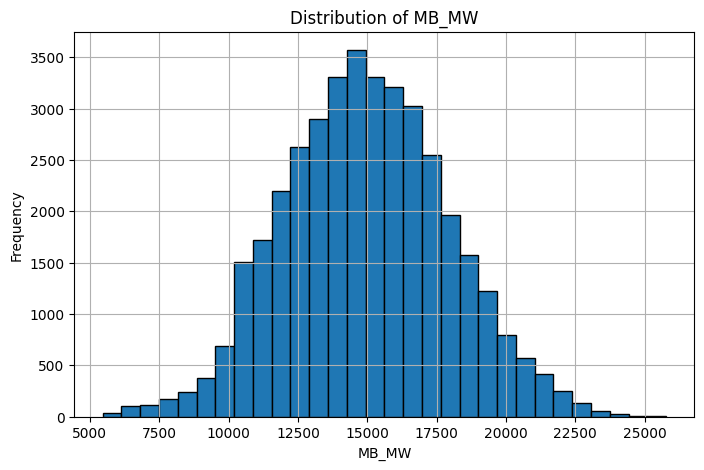

In [778]:
col = 'MB_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

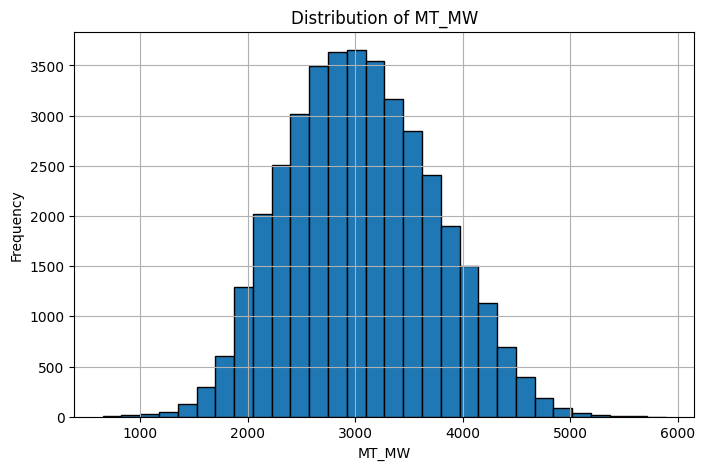

In [779]:
col = 'MT_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

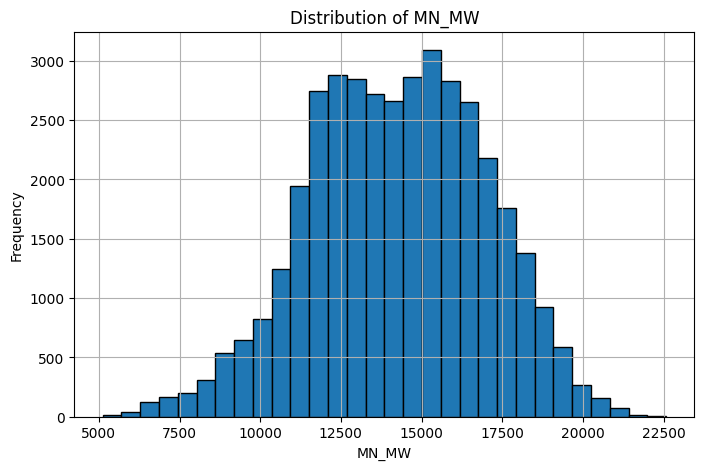

In [780]:
col = 'MN_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_20088\1286020358.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_sum = df.resample("Y").sum()


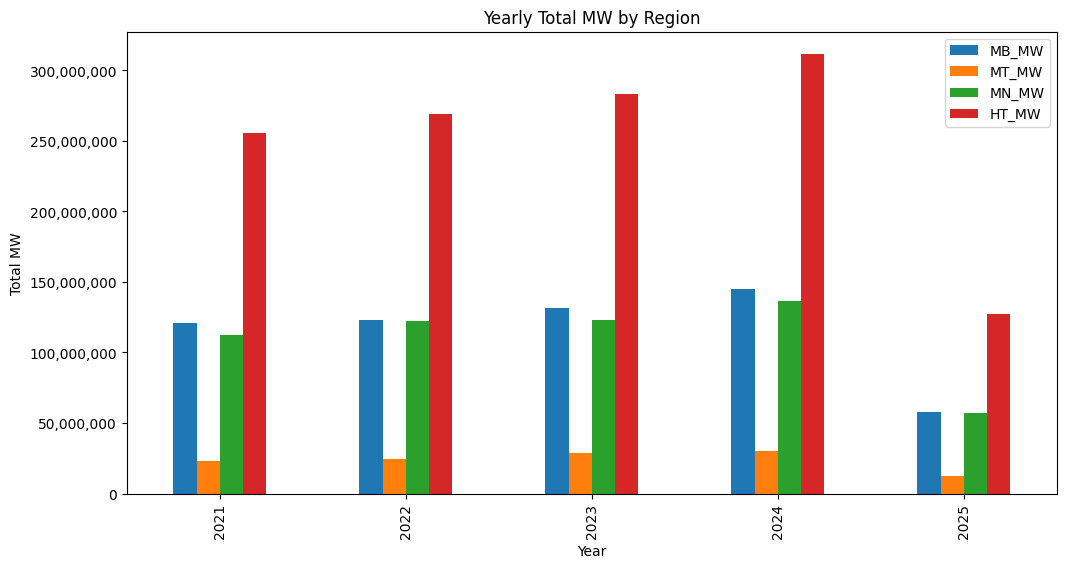

In [781]:
# Group by year and sum
df_yearly_sum = df.resample("Y").sum()
df_yearly_sum.index = df_yearly_sum.index.year

ax = df_yearly_sum.plot(kind="bar", figsize=(12,6))
plt.title("Yearly Total MW by Region")
plt.xlabel("Year")
plt.ylabel("Total MW")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_20088\4107936705.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_avg = df.resample("Y").mean()


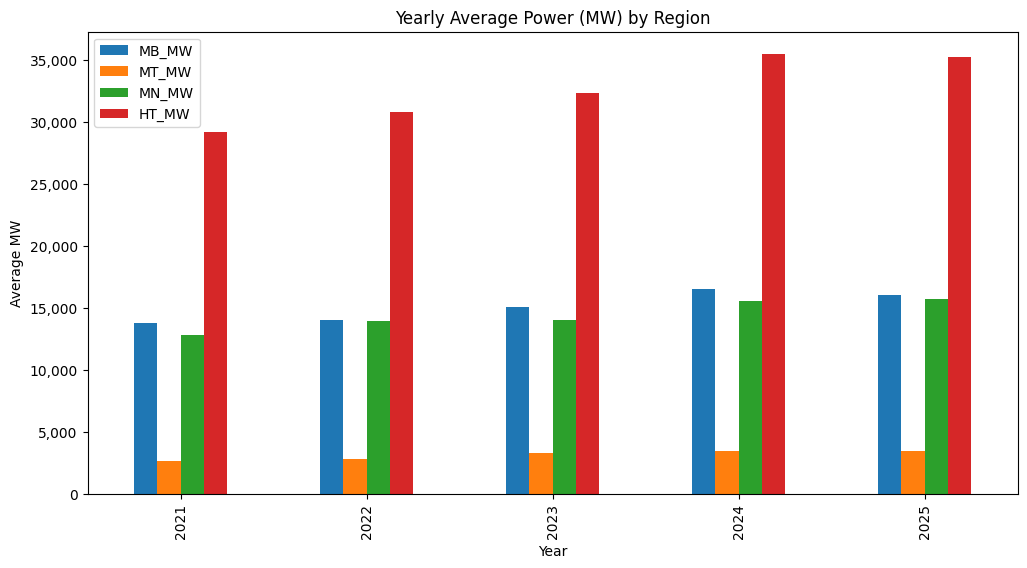

In [782]:
df_yearly_avg = df.resample("Y").mean()
df_yearly_avg.index = df_yearly_avg.index.year

ax = df_yearly_avg.plot(kind="bar", figsize=(12,6))
ax.set_title("Yearly Average Power (MW) by Region")
ax.set_xlabel("Year")
ax.set_ylabel("Average MW")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # no scientific notation
plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_20088\1457046368.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").sum()


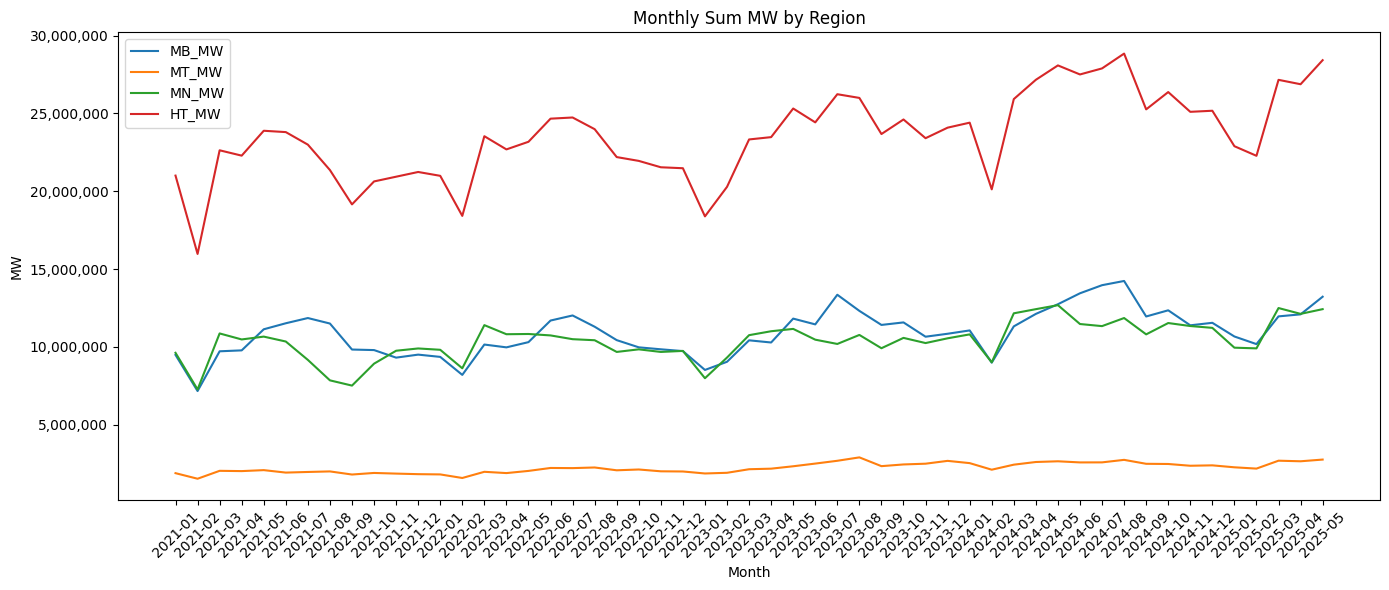

In [783]:
# Monthly cumulative (summing each month)
df_monthly = df.resample("M").sum()
df_monthly.index = df_monthly.index.to_period("M")

# Plot as line chart
fig, ax = plt.subplots(figsize=(14,6))
for col in df_monthly.columns:
    ax.plot(df_monthly.index.astype(str), df_monthly[col], label=col)

ax.set_title("Monthly Sum MW by Region")
ax.set_xlabel("Month")
ax.set_ylabel("MW")

# Format y-axis without scientific notation, add thousands separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_20088\3306824259.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").mean()


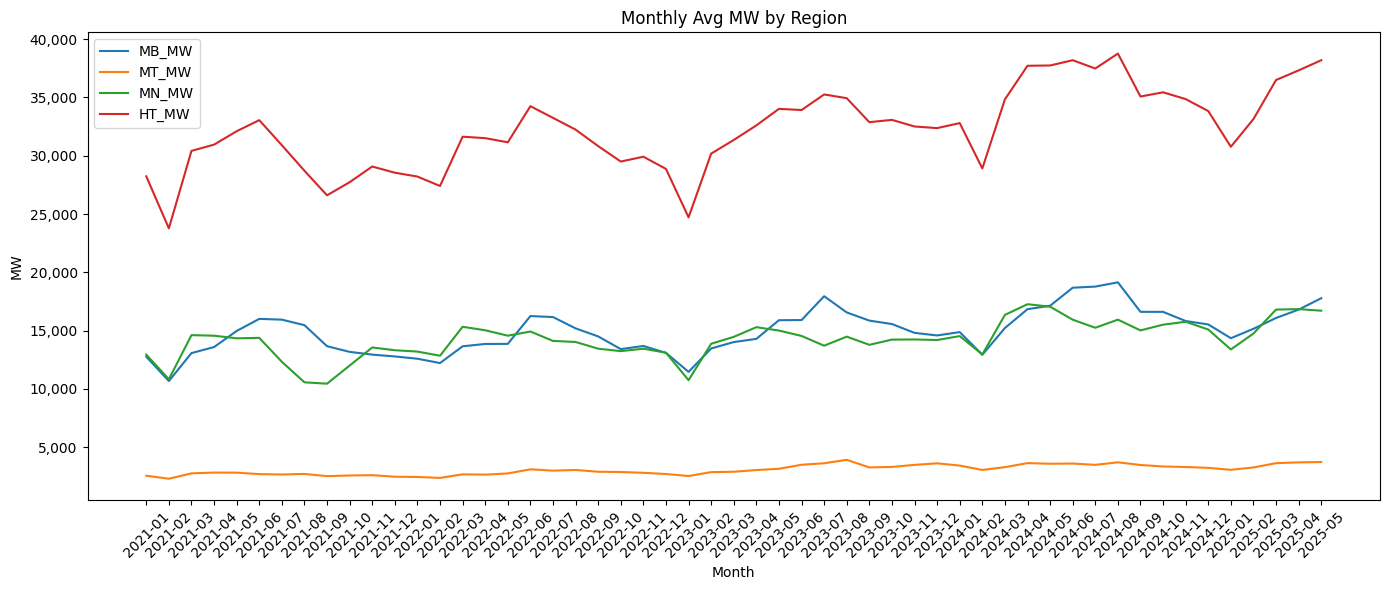

In [784]:
# Monthly cumulative (summing each month)
df_monthly = df.resample("M").mean()
df_monthly.index = df_monthly.index.to_period("M")

# Plot as line chart
fig, ax = plt.subplots(figsize=(14,6))
for col in df_monthly.columns:
    ax.plot(df_monthly.index.astype(str), df_monthly[col], label=col)

ax.set_title("Monthly Avg MW by Region")
ax.set_xlabel("Month")
ax.set_ylabel("MW")

# Format y-axis without scientific notation, add thousands separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [785]:
pred_df = pd.read_csv("./results/VN_Energy_4320_720_200_PatchTST_VN_Energy_ftM_sl4320_ll48_pl720_dm16_nh4_el3_dl1_df128_fc1_ebtimeF_dtTrue_Exp_0/rolling_pred_4320_720_until_2050-12-31.csv")

In [786]:
pred_df["Unnamed: 0"] = pd.to_datetime(pred_df["Unnamed: 0"])
pred_df = pred_df.set_index("Unnamed: 0")
pred_df.index.name = "date"

# Recompute HT_MW as sum of the 3 columns
pred_df["HT_MW"] = pred_df[["MB_MW", "MT_MW", "MN_MW"]].sum(axis=1)

In [787]:
# # 3-month cumulative (summing every 3 months)
# pred_df_3m = pred_df.resample("3M").sum()
# pred_df_3m.index = pred_df_3m.index.to_period("Q")  # show as quarter period (e.g. 2025Q1)

# # Plot as line chart
# fig, ax = plt.subplots(figsize=(14,6))
# for col in pred_df_3m.columns:
#     ax.plot(pred_df_3m.index.astype(str), pred_df_3m[col], label=col)

# ax.set_title("3-Month Sum MW by Region")
# ax.set_xlabel("Quarter")
# ax.set_ylabel("MW")

# # Format y-axis without scientific notation, add thousands separator
# ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# plt.xticks(rotation=45)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [788]:
# # 6-month cumulative (summing every 6 months)
# pred_df_6m = pred_df.resample("6M").sum()
# pred_df_6m.index = pred_df_6m.index.to_period("2Q")  # every 2 quarters

# # Plot as line chart
# fig, ax = plt.subplots(figsize=(14,6))
# for col in pred_df_6m.columns:
#     ax.plot(pred_df_6m.index.astype(str), pred_df_6m[col], label=col)

# ax.set_title("6-Month Sum MW by Region")
# ax.set_xlabel("Half-Year")
# ax.set_ylabel("MW")

# # Format y-axis without scientific notation, add thousands separator
# ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# plt.xticks(rotation=45)
# plt.legend()
# plt.tight_layout()
# plt.show()


In [789]:
pred_df.shape

(224280, 4)

In [790]:
pred_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 224280 entries, 2025-06-01 00:00:00 to 2050-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   MB_MW   224280 non-null  float64
 1   MT_MW   224280 non-null  float64
 2   MN_MW   224280 non-null  float64
 3   HT_MW   224280 non-null  float64
dtypes: float64(4)
memory usage: 8.6 MB


In [791]:
pred_df.columns

Index(['MB_MW', 'MT_MW', 'MN_MW', 'HT_MW'], dtype='object')

In [792]:
pred_df.tail(10)

,MB_MW,MT_MW,MN_MW,HT_MW
date,,,,
2050-12-31 14:00:00,"-492,864","-101,850","-511,218","-1,105,931"
2050-12-31 15:00:00,"-487,877","-100,817","-506,018","-1,094,712"
2050-12-31 16:00:00,"-511,168","-105,655","-530,204","-1,147,027"
2050-12-31 17:00:00,"-538,251","-111,276","-558,354","-1,207,881"
2050-12-31 18:00:00,"-545,872","-112,856","-566,289","-1,225,017"
2050-12-31 19:00:00,"-525,909","-108,710","-545,554","-1,180,173"
2050-12-31 20:00:00,"-500,461","-103,428","-519,105","-1,122,994"
2050-12-31 21:00:00,"-475,385","-98,222","-493,051","-1,066,658"
2050-12-31 22:00:00,"-460,231","-95,076","-477,304","-1,032,611"


In [793]:
pred_df.head()

,MB_MW,MT_MW,MN_MW,HT_MW
date,,,,
2025-06-01 00:00:00,"17,002","3,497","15,005","35,503"
2025-06-01 01:00:00,"16,000","3,345","14,313","33,658"
2025-06-01 02:00:00,"15,532","3,123","13,276","31,932"
2025-06-01 03:00:00,"14,951","3,052","12,896","30,899"
2025-06-01 04:00:00,"14,834","3,104","12,837","30,775"


In [794]:
final_df = pd.concat([df, pred_df], axis=0)

final_df.head()

,MB_MW,MT_MW,MN_MW,HT_MW
date,,,,
2021-01-01 00:00:00,"8,776","1,705","10,259","20,741"
2021-01-01 01:00:00,"8,763","1,619","10,020","20,402"
2021-01-01 02:00:00,"8,740","1,662","9,871","20,273"
2021-01-01 03:00:00,"8,735","1,675","9,719","20,128"
2021-01-01 04:00:00,"8,610","1,664","9,453","19,727"


In [795]:
final_df.tail(10)

,MB_MW,MT_MW,MN_MW,HT_MW
date,,,,
2050-12-31 14:00:00,"-492,864","-101,850","-511,218","-1,105,931"
2050-12-31 15:00:00,"-487,877","-100,817","-506,018","-1,094,712"
2050-12-31 16:00:00,"-511,168","-105,655","-530,204","-1,147,027"
2050-12-31 17:00:00,"-538,251","-111,276","-558,354","-1,207,881"
2050-12-31 18:00:00,"-545,872","-112,856","-566,289","-1,225,017"
2050-12-31 19:00:00,"-525,909","-108,710","-545,554","-1,180,173"
2050-12-31 20:00:00,"-500,461","-103,428","-519,105","-1,122,994"
2050-12-31 21:00:00,"-475,385","-98,222","-493,051","-1,066,658"
2050-12-31 22:00:00,"-460,231","-95,076","-477,304","-1,032,611"


In [796]:
mask = (final_df.index >= "2025-06-01") & (final_df.index <= "2025-12-31")
subset = final_df.loc[mask]

print(subset)


                     MB_MW  MT_MW  MN_MW  HT_MW
date                                           
2025-06-01 00:00:00 17,002  3,497 15,005 35,503
2025-06-01 01:00:00 16,000  3,345 14,313 33,658
2025-06-01 02:00:00 15,532  3,123 13,276 31,932
2025-06-01 03:00:00 14,951  3,052 12,896 30,899
2025-06-01 04:00:00 14,834  3,104 12,837 30,775
...                    ...    ...    ...    ...
2025-12-30 20:00:00 22,416  4,616 16,618 43,649
2025-12-30 21:00:00 22,162  4,689 16,742 43,592
2025-12-30 22:00:00 21,671  4,593 15,786 42,049
2025-12-30 23:00:00 21,071  4,348 14,637 40,056
2025-12-31 00:00:00 19,940  4,157 13,255 37,351

[5113 rows x 4 columns]


In [797]:
subset.head(100)
subset.to_csv("subset.csv")

In [798]:
df_yearly_max = final_df["HT_MW"].resample("Y").max()
df_yearly_max.index = df_yearly_max.index.year  # đổi index thành năm (2021, 2022, ...)

C:\Users\Hi\AppData\Local\Temp\ipykernel_20088\4161190720.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_max = final_df["HT_MW"].resample("Y").max()


In [799]:
years = [2025, 2030, 2035, 2040, 2045, 2050]
df_yearly_max.loc[years]

date
2025     50,032
2030     56,528
2035     25,041
2040    -95,032
2045   -339,331
2050   -867,955
Name: HT_MW, dtype: float64

In [800]:
df_yearly_sum = final_df.resample("Y").sum()
df_yearly_sum.index = df_yearly_sum.index.year  # đổi index thành năm (2021, 2022, ...)

C:\Users\Hi\AppData\Local\Temp\ipykernel_20088\4229388793.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_sum = final_df.resample("Y").sum()


In [801]:
df_yearly_sum.head(100)

,MB_MW,MT_MW,MN_MW,HT_MW
date,,,,
2021,"120,619,922","22,893,838","112,374,565","255,888,325"
2022,"123,009,648","24,231,484","122,111,478","269,352,610"
2023,"131,708,001","28,535,398","122,964,946","283,208,345"
2024,"145,135,723","30,014,102","136,664,914","311,814,738"
2025,"162,506,132","33,884,942","132,478,689","328,869,765"
2026,"184,899,271","40,691,071","132,742,353","358,332,694"
2027,"197,774,700","44,109,475","157,426,547","399,310,722"
2028,"203,459,709","44,915,791","169,805,645","418,181,145"
2029,"201,968,198","44,314,902","171,961,423","418,244,524"


In [802]:
years = [2025, 2030, 2035, 2040, 2045, 2050]
df_yearly_sum.loc[years, 'HT_MW']

date
2025      328,869,765
2030      409,801,078
2035       -2,285,238
2040   -1,284,848,313
2045   -3,944,713,543
2050   -9,709,962,041
Name: HT_MW, dtype: float64